# 06 — Synthetic Pyrolysis Case Study

A personal implementation inspired by the Chapter 5 unsupervised-learning case study in *AI in Chemical Engineering: Unlocking the Power Within Data* by Romagnoli, Briceño-Mena, and Manee.

## Data and scope

This notebook creates a synthetic dataset with 8,000 observations across a designed 90-day operating cycle and six coils. Baseline values are informed by the book, while trends, relationships, noise, and injected anomalies are constructed for this exercise. **These are not plant data.** The notebook does not include a direct coke-deposition measurement; coking or fouling is not measured or independently modeled here.

## What it explores

- PCA and component loadings
- Injected outliers and k-nearest-neighbor anomaly scores
- Sampling and DBSCAN
- PaCMAP and t-SNE visualizations, including exploratory clustering

Because the variables contain imposed time-dependent patterns, a cycle-like projection is expected. Treat the results as a learning exercise, not as a validated process diagnosis.


In [ ]:
!pip install umap-learn pacmap hdbscan

In [37]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import pacmap

# Clustering
from sklearn.cluster import DBSCAN, KMeans
import hdbscan

# Evaluation
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [38]:
np.random.seed(42)

n_samples = 8000

# 90-day operating cycle
days = np.linspace(0, 90, n_samples)

# Normalized time for generating process drift
time = days / 90

hc_mean = np.array([
    8729, 8287, 8851, 8586, 8431, 8879
])

steam_mean = np.array([
    4285, 4464, 4361, 4272, 4320, 4317
])

crossover_temp_mean = np.array([
    611, 617, 621, 611, 618, 622
])

cracking_temp_mean = np.array([
    832, 837, 835, 836, 837, 838
])

furnace_temp_mean = 1026
outlet_temp_mean = 838

In [39]:
# Generate hydrocarbon flow for 6 coils

hc_flows = {}

for i in range(6):
    drift = -(150 + 20 * i) * time
    nonlinear = 40 * np.sin(2 * np.pi * time + i * 0.3)
    noise = np.random.normal(0, 25, n_samples)

    hc_flows[f"HC_Flow_Coil_{i+1}"] = (
        hc_mean[i]
        + drift
        + nonlinear
        + noise
    )

In [40]:
df = pd.DataFrame(hc_flows) #put them in dataframe

df["Time_Days"] = days

df.head()

,HC_Flow_Coil_1,HC_Flow_Coil_2,HC_Flow_Coil_3,HC_Flow_Coil_4,HC_Flow_Coil_5,HC_Flow_Coil_6,Time_Days
0,8741.417854,8297.995177,8895.568381,8600.548738,8486.581920,8907.103361,0.000000
1,8725.556060,8286.238312,8874.570601,8599.481358,8427.975043,8944.188318,0.011251
2,8745.217548,8294.528947,8850.781891,8652.954741,8451.338131,8913.887016,0.022503
3,8767.113749,8316.715360,8862.029694,8663.923164,8434.028156,8921.076826,0.033754
4,8723.196835,8330.802222,8882.165640,8594.083971,8472.944432,8936.718242,0.045006


The synthetic dataset currently contains 8,000 observations, six hydrocarbon-flow measurements, and a time column. Additional variables are added in the following cells to build a multivariate process representation.


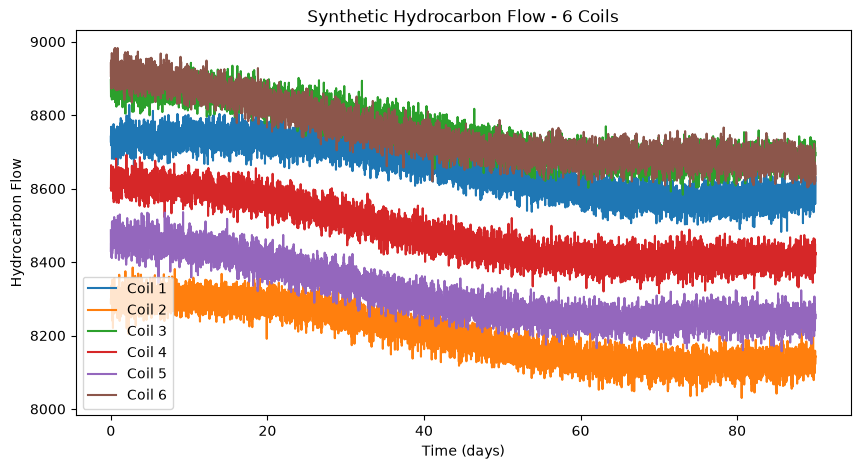

In [41]:
plt.figure(figsize=(10, 5))

for i in range(1, 7):
    plt.plot(df["Time_Days"], df[f"HC_Flow_Coil_{i}"], label=f"Coil {i}")

plt.xlabel("Time (days)")
plt.ylabel("Hydrocarbon Flow")
plt.title("Synthetic Hydrocarbon Flow - 6 Coils")
plt.legend()

plt.show()

Steam-flow variables are generated with a relationship to hydrocarbon flow, plus drift and noise. This creates correlated variables while allowing steam flow to evolve differently from hydrocarbon flow.


In [42]:
# Generate steam flow for 6 coils

steam_flows = {}

for i in range(6):
    hc_effect = -0.25 * (hc_flows[f"HC_Flow_Coil_{i+1}"] - hc_mean[i])
    drift = 120 * time  #steam’in cycle boyunca genel olarak yükselmesine izin veriyor.
    noise = np.random.normal(0, 20, n_samples)

    steam_flows[f"Steam_Flow_Coil_{i+1}"] = (
        steam_mean[i]
        + hc_effect
        + drift
        + noise
    )

Hydrocarbon flow decreases while steam flow increases in parts of the designed operating cycle. This relationship is imposed in the synthetic data; it is not estimated from plant measurements.


In [43]:
for column, values in steam_flows.items():
    df[column] = values

df.head()

,HC_Flow_Coil_1,HC_Flow_Coil_2,HC_Flow_Coil_3,HC_Flow_Coil_4,HC_Flow_Coil_5,HC_Flow_Coil_6,Time_Days,Steam_Flow_Coil_1,Steam_Flow_Coil_2,Steam_Flow_Coil_3,Steam_Flow_Coil_4,Steam_Flow_Coil_5,Steam_Flow_Coil_6
0,8741.417854,8297.995177,8895.568381,8600.548738,8486.581920,8907.103361,0.000000,4294.046955,4472.684685,4346.071772,4254.960249,4319.384541,4309.639023
1,8725.556060,8286.238312,8874.570601,8599.481358,8427.975043,8944.188318,0.011251,4271.299042,4481.344508,4351.100760,4272.076615,4314.848920,4309.360878
2,8745.217548,8294.528947,8850.781891,8652.954741,8451.338131,8913.887016,0.022503,4275.586572,4476.122597,4355.789341,4239.224966,4313.613743,4315.976238
3,8767.113749,8316.715360,8862.029694,8663.923164,8434.028156,8921.076826,0.033754,4271.119641,4460.751496,4374.140324,4233.132090,4315.780319,4258.846737
4,8723.196835,8330.802222,8882.165640,8594.083971,8472.944432,8936.718242,0.045006,4286.201980,4458.401296,4370.311716,4266.086714,4319.854973,4306.394093


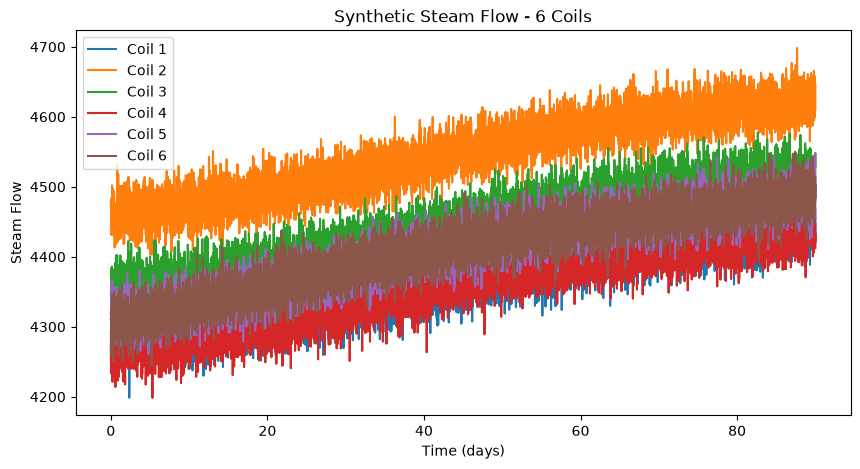

In [44]:
plt.figure(figsize=(10, 5))

for i in range(1, 7):
    plt.plot(
        df["Time_Days"],
        df[f"Steam_Flow_Coil_{i}"],
        label=f"Coil {i}"
    )

plt.xlabel("Time (days)")
plt.ylabel("Steam Flow")
plt.title("Synthetic Steam Flow - 6 Coils")
plt.legend()

plt.show()

The initial pattern was too linear, so the synthetic trend was revised to include nonlinear variation.


In [45]:
# Generate steam flow for 6 coils

steam_flows = {}

for i in range(6):
    hc_effect = -0.20 * (
        hc_flows[f"HC_Flow_Coil_{i+1}"] - hc_mean[i]
    )

    nonlinear_drift = (
        60 * time
        + 80 * time**2
        + 25 * np.sin(4 * np.pi * time + i * 0.4)
    )

    noise = np.random.normal(0, 20, n_samples)

    steam_flows[f"Steam_Flow_Coil_{i+1}"] = (
        steam_mean[i]
        + hc_effect
        + nonlinear_drift
        + noise
    )

In [46]:
for column, values in steam_flows.items():
    df[column] = values

df.head()

,HC_Flow_Coil_1,HC_Flow_Coil_2,HC_Flow_Coil_3,HC_Flow_Coil_4,HC_Flow_Coil_5,HC_Flow_Coil_6,Time_Days,Steam_Flow_Coil_1,Steam_Flow_Coil_2,Steam_Flow_Coil_3,Steam_Flow_Coil_4,Steam_Flow_Coil_5,Steam_Flow_Coil_6
0,8741.417854,8297.995177,8895.568381,8600.548738,8486.581920,8907.103361,0.000000,4292.817589,4457.816105,4351.397797,4288.018224,4342.833170,4350.999355
1,8725.556060,8286.238312,8874.570601,8599.481358,8427.975043,8944.188318,0.011251,4279.154522,4480.723853,4393.943693,4300.285182,4343.117058,4312.794858
2,8745.217548,8294.528947,8850.781891,8652.954741,8451.338131,8913.887016,0.022503,4308.409364,4427.903757,4380.758362,4296.656223,4360.078448,4322.850270
3,8767.113749,8316.715360,8862.029694,8663.923164,8434.028156,8921.076826,0.033754,4253.529673,4445.866753,4369.418628,4256.114002,4361.755807,4338.182226
4,8723.196835,8330.802222,8882.165640,8594.083971,8472.944432,8936.718242,0.045006,4298.568711,4427.902122,4393.592158,4295.785452,4339.256919,4303.065508


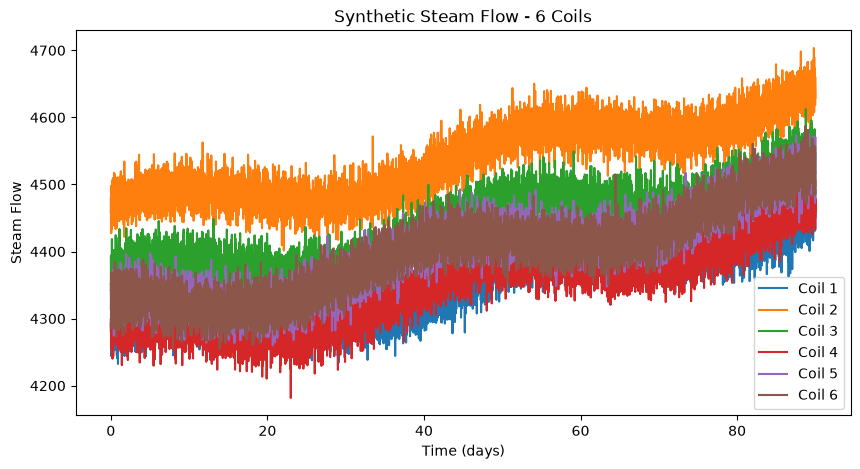

In [47]:
plt.figure(figsize=(10, 5))

for i in range(1, 7):
    plt.plot(
        df["Time_Days"],
        df[f"Steam_Flow_Coil_{i}"],
        label=f"Coil {i}"
    )

plt.xlabel("Time (days)")
plt.ylabel("Steam Flow")
plt.title("Synthetic Steam Flow - 6 Coils")
plt.legend()

plt.show()

In [48]:
print(df.shape)
print(df.columns.tolist())

(8000, 13)
['HC_Flow_Coil_1', 'HC_Flow_Coil_2', 'HC_Flow_Coil_3', 'HC_Flow_Coil_4', 'HC_Flow_Coil_5', 'HC_Flow_Coil_6', 'Time_Days', 'Steam_Flow_Coil_1', 'Steam_Flow_Coil_2', 'Steam_Flow_Coil_3', 'Steam_Flow_Coil_4', 'Steam_Flow_Coil_5', 'Steam_Flow_Coil_6']


In [49]:
# Generate crossover temperatures for 6 coils

crossover_temps = {}

for i in range(6):
    hc_deviation = (
        hc_flows[f"HC_Flow_Coil_{i+1}"] - hc_mean[i]
    )

    steam_deviation = (
        steam_flows[f"Steam_Flow_Coil_{i+1}"] - steam_mean[i]
    )

    process_effect = (
        -0.004 * hc_deviation
        + 0.006 * steam_deviation
        + 3 * time**2
    )

    noise = np.random.normal(0, 0.8, n_samples)

    crossover_temps[f"Crossover_Temp_Coil_{i+1}"] = (
        crossover_temp_mean[i]
        + process_effect
        + noise
    )

In [50]:
for column, values in crossover_temps.items():
    df[column] = values

print(df.shape)

(8000, 19)


The dataset now contains 19 variables. Six cracking-temperature variables are added next.


In [51]:
# Generate cracking temperatures for 6 coils

cracking_temps = {}

for i in range(6):
    crossover_deviation = (
        crossover_temps[f"Crossover_Temp_Coil_{i+1}"]
        - crossover_temp_mean[i]
    )

    process_effect = (
        0.35 * crossover_deviation
        + 2.5 * time
        + 1.5 * time**2
    )

    noise = np.random.normal(0, 0.6, n_samples)

    cracking_temps[f"Cracking_Temp_Coil_{i+1}"] = (
        cracking_temp_mean[i]
        + process_effect
        + noise
    )

In [52]:
for column, values in cracking_temps.items():
    df[column] = values

print(df.shape)

(8000, 25)


The 25 columns comprise six hydrocarbon-flow measurements, six steam-flow measurements, six crossover temperatures, six cracking temperatures, and one time column.


In [53]:
# Global process variables

df["Total_HC_Flow"] = sum(
    df[f"HC_Flow_Coil_{i}"] for i in range(1, 7)
)

df["Overall_Outlet_Temp"] = (
    np.mean(
        [df[f"Cracking_Temp_Coil_{i}"] for i in range(1, 7)],
        axis=0
    )
    + np.random.normal(0, 0.4, n_samples)
)

df["Furnace_Temp"] = (
    1026
    + 8 * time
    + 5 * time**2
    + 2 * np.sin(2 * np.pi * time)
    + np.random.normal(0, 1.5, n_samples)
)

Three aggregate variables are constructed: total hydrocarbon flow, mean outlet temperature with small noise, and furnace temperature with a baseline, drift, nonlinear component, and noise.


In [54]:
print(df.shape)
print(df.columns.tolist())

(8000, 28)
['HC_Flow_Coil_1', 'HC_Flow_Coil_2', 'HC_Flow_Coil_3', 'HC_Flow_Coil_4', 'HC_Flow_Coil_5', 'HC_Flow_Coil_6', 'Time_Days', 'Steam_Flow_Coil_1', 'Steam_Flow_Coil_2', 'Steam_Flow_Coil_3', 'Steam_Flow_Coil_4', 'Steam_Flow_Coil_5', 'Steam_Flow_Coil_6', 'Crossover_Temp_Coil_1', 'Crossover_Temp_Coil_2', 'Crossover_Temp_Coil_3', 'Crossover_Temp_Coil_4', 'Crossover_Temp_Coil_5', 'Crossover_Temp_Coil_6', 'Cracking_Temp_Coil_1', 'Cracking_Temp_Coil_2', 'Cracking_Temp_Coil_3', 'Cracking_Temp_Coil_4', 'Cracking_Temp_Coil_5', 'Cracking_Temp_Coil_6', 'Total_HC_Flow', 'Overall_Outlet_Temp', 'Furnace_Temp']


In [55]:
feature_columns = [
    col for col in df.columns
    if col != "Time_Days"
]

X = df[feature_columns]

print("Dataset shape:", X.shape)

Dataset shape: (8000, 27)


Create the feature list from every dataframe column except `Time_Days`. Time is retained separately for coloring plots and is not included as a model feature.


In [56]:
#standartization zamanı sımdı
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [57]:
#pca yapalım
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)
print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Original shape: (8000, 27)
Reduced shape: (8000, 2)
Explained variance: [0.8215946 0.0275095]
Total explained variance: 0.8491041049809629


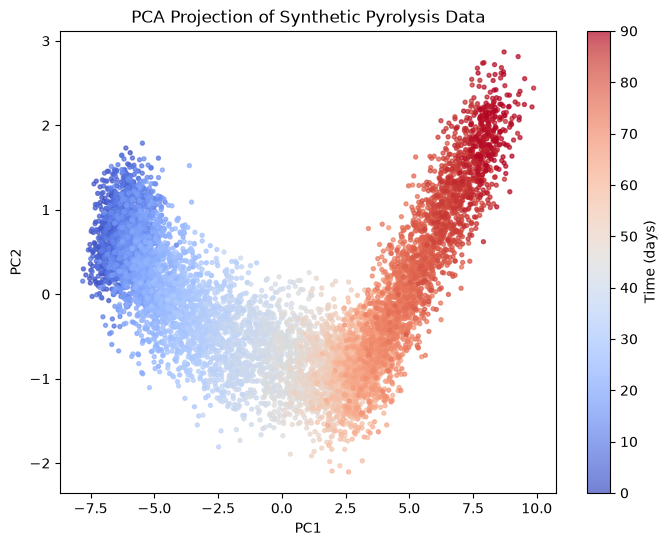

In [58]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Time_Days"],
    cmap="coolwarm",
    s=8,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Synthetic Pyrolysis Data")

plt.colorbar(scatter, label="Time (days)")

plt.show()

The variables were generated with time-dependent trends, so PCA is expected to reflect the designed operating-cycle progression. This is a check of the synthetic construction, not evidence that PCA independently discovered a real plant cycle or coking behavior.


In [59]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.8215946 0.0275095]
0.8491041049809629


PC1 explains most of the variance in this generated dataset. The next step is to inspect the component loadings and understand which variables contribute to the projection.


In [60]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_columns,
    columns=["PC1", "PC2"]
)

loadings

,PC1,PC2
HC_Flow_Coil_1,-0.195404,0.128187
HC_Flow_Coil_2,-0.196437,0.226278
HC_Flow_Coil_3,-0.195425,0.303500
HC_Flow_Coil_4,-0.193197,0.360020
HC_Flow_Coil_5,-0.189505,0.399817
HC_Flow_Coil_6,-0.188793,0.376764
Steam_Flow_Coil_1,0.187044,0.036098
Steam_Flow_Coil_2,0.190280,0.025108
Steam_Flow_Coil_3,0.191941,0.040698
Steam_Flow_Coil_4,0.194165,0.035372


In [61]:
pc1_importance = loadings["PC1"].abs().sort_values(ascending=False)

print(pc1_importance)

Overall_Outlet_Temp      0.204080
Total_HC_Flow            0.203696
Cracking_Temp_Coil_4     0.197818
Cracking_Temp_Coil_3     0.197191
Cracking_Temp_Coil_6     0.197181
Cracking_Temp_Coil_5     0.196934
Cracking_Temp_Coil_1     0.196619
Cracking_Temp_Coil_2     0.196517
HC_Flow_Coil_2           0.196437
HC_Flow_Coil_3           0.195425
HC_Flow_Coil_1           0.195404
Steam_Flow_Coil_5        0.194249
Steam_Flow_Coil_4        0.194165
Steam_Flow_Coil_6        0.193746
HC_Flow_Coil_4           0.193197
Steam_Flow_Coil_3        0.191941
Steam_Flow_Coil_2        0.190280
HC_Flow_Coil_5           0.189505
HC_Flow_Coil_6           0.188793
Crossover_Temp_Coil_4    0.188046
Crossover_Temp_Coil_5    0.187581
Crossover_Temp_Coil_6    0.187530
Crossover_Temp_Coil_3    0.187400
Steam_Flow_Coil_1        0.187044
Crossover_Temp_Coil_2    0.186085
Crossover_Temp_Coil_1    0.184734
Furnace_Temp             0.171663
Name: PC1, dtype: float64


The sign of a loading indicates direction, not importance by itself. Here, PC1 combines the shared behavior of several process variables. PC2 captures a smaller part of the variation, including differences among coils and furnace behavior. These interpretations describe this synthetic dataset.


## PCA Results and Interpretation

Principal Component Analysis (PCA) was applied to the standardized 27-dimensional synthetic pyrolysis dataset in order to investigate whether the main structure of the process could be represented in a lower-dimensional space.

The first two principal components explain the following fractions of the total variance:

- **PC1:** 82.14%
- **PC2:** 2.77%
- **PC1 + PC2:** 84.92%

This means that approximately **84.9% of the total variance in the 27-dimensional process dataset can be represented using only two principal components**. Most of this information is captured by PC1 alone.

It is important to note that the explained variance ratio does not indicate the importance of individual process variables. Instead, it indicates how much of the total variation in the dataset is represented by each principal component.

The contribution of individual variables to each principal component can be investigated using the PCA loadings.

### Interpretation of PC1

The PC1 loadings show that a large number of process variables contribute with similar magnitudes.

Some of the largest absolute PC1 loadings are associated with:

- Overall outlet temperature
- Total hydrocarbon flow
- Cracking temperatures
- Individual hydrocarbon flows
- Steam flows
- Crossover temperatures

However, there is no single variable that dominates PC1. Most of the absolute loading values are in a relatively narrow range of approximately 0.17–0.20.

This suggests that PC1 does not represent the behavior of one individual sensor or one single physical quantity. Instead, it captures a **common multivariate process trend** involving many variables simultaneously.

The signs of the loadings provide additional information about the direction of this process trend.

The hydrocarbon flow variables have negative PC1 loadings, while steam flows and most temperature-related variables have positive PC1 loadings.

Therefore, PC1 can approximately be interpreted as a contrast between:

\[
\text{decreasing hydrocarbon flow}
\]

and

\[
\text{increasing steam and temperature-related variables}
\]

during the operating cycle.

This interpretation is consistent with the way the synthetic dataset was constructed. Hydrocarbon flows were generated with a gradual negative drift, whereas steam flows and temperature variables were designed to increase or change as the operating cycle progressed.

Therefore, PCA successfully identified the dominant coordinated process behavior without being explicitly provided with the time variable.

### Relationship Between PC1 and Operating Time

The variable `Time_Days` was deliberately excluded from the PCA input.

Therefore, PCA only received the 27 process measurements and had no direct information about the position of each sample within the 90-day operating cycle.

Despite this, coloring the PCA projection using `Time_Days` produced a clear transition from early-cycle samples to late-cycle samples.

Early observations appear mainly on the negative side of PC1, whereas late-cycle observations appear mainly on the positive side.

This indicates that the process measurements themselves contain enough information to encode the progression of the operating cycle.

In other words, PCA was able to detect a latent process trajectory using only the multivariate relationships between the measured variables.

The dominant process evolution can therefore be summarized approximately as:

\[
\text{Early cycle}
\rightarrow
\text{Process drift}
\rightarrow
\text{Late cycle}
\]

with this progression occurring primarily along PC1.

### Interpretation of PC2

PC2 explains only approximately 2.77% of the total variance, which means that it represents a much smaller secondary source of variation compared with PC1.

The PC2 loadings show a different pattern from PC1.

Several hydrocarbon flow variables have relatively large PC2 loadings, particularly some of the later coils, while steam flow variables generally have much smaller PC2 loadings.

Furnace temperature also has a comparatively large loading on PC2.

This suggests that PC2 may primarily describe differences between individual hydrocarbon coils and secondary furnace-related behavior that is not captured by the dominant process drift represented by PC1.

Because PC2 represents only a small fraction of the total variance, it should not be interpreted as the primary operating trend.

Instead, it can be considered a secondary variation superimposed on the dominant operating-cycle progression.

### Interpretation of the PCA Projection Shape

The PCA projection forms a curved, approximately U-shaped trajectory rather than a straight line or a set of clearly separated clusters.

This is expected because the synthetic dataset contains several nonlinear relationships.

For example, the generated process variables include:

- quadratic time-dependent drift,
- sinusoidal variations,
- dependencies between hydrocarbon flow and steam flow,
- dependencies between flow variables and temperature variables.

As a result, the underlying process evolution is not purely linear.

PCA is a linear dimensionality reduction technique. It searches for linear combinations of the original variables that maximize variance.

Therefore, although PCA captures most of the total variance, it does not necessarily preserve the full nonlinear geometry of the original process.

The curved shape of the 2D projection may therefore indicate that the original high-dimensional process follows a nonlinear trajectory that PCA is representing using linear axes.

This distinction is important:

> A high explained variance does not necessarily mean that PCA perfectly preserves the nonlinear structure of the dataset.

The first two principal components retain approximately 84.9% of the variance, but nonlinear relationships and local neighborhood structures may still be distorted during the projection.

### Clustering Interpretation

The PCA projection does not show several clearly separated groups.

Instead, the samples form a continuous trajectory from the beginning to the end of the operating cycle.

This is consistent with the way the synthetic dataset was generated.

The process was modeled as a gradually evolving system rather than as a system containing several discrete operating regimes.

Therefore, the observed structure is better interpreted as continuous process evolution rather than a set of naturally separated clusters.

This distinction will become important when clustering algorithms such as DBSCAN or HDBSCAN are applied.

A clustering algorithm may divide this continuous trajectory into different regions, but these regions should not automatically be interpreted as physically distinct process states.

### Main Conclusion

The PCA analysis indicates that the synthetic pyrolysis process contains a strong common multivariate operating trend.

PC1 alone explains approximately 82.14% of the total variance and is influenced by nearly all process variables.

Hydrocarbon flows contribute to PC1 mainly in the negative direction, while steam flows and temperature-related variables contribute mainly in the positive direction.

The clear time-dependent progression observed in the PCA projection, despite excluding `Time_Days` from the PCA input, demonstrates that the process variables themselves encode the evolution of the operating cycle.

At the same time, the curved PCA trajectory suggests that the synthetic process contains nonlinear structure that may not be fully represented by a linear dimensionality reduction method.

For this reason, PCA provides a useful baseline representation of the process, but nonlinear dimensionality reduction techniques such as UMAP, PaCMAP, or t-SNE may provide additional information about the local and nonlinear structure of the dataset.

In this synthetic setup, the dominant PC1 direction combines decreasing hydrocarbon flow with changes in steam and temperature-related variables.


## 5.3 PCA and the Effect of Outliers


In [102]:
# ============================================================
# CREATE OUTLIER DATASET
# ============================================================

# Keep the original clean dataset unchanged
df_outlier = df.copy()


# --- 1. Univariate outliers ---
# Only one variable is extremely abnormal in each observation

df_outlier.loc[100, "HC_Flow_Coil_1"] = 14000
# Extremely high hydrocarbon flow

df_outlier.loc[500, "Steam_Flow_Coil_3"] = 7500
# Extremely high steam flow

df_outlier.loc[1000, "Crossover_Temp_Coil_2"] = 750
# Abnormally high crossover temperature

df_outlier.loc[1500, "Cracking_Temp_Coil_5"] = 1000
# Abnormally high cracking temperature

df_outlier.loc[2000, "Furnace_Temp"] = 1400
# Extremely high furnace temperature


# --- 2. Multiple extreme values in the same observation ---
# Several variables become abnormal simultaneously

df_outlier.loc[3000, "HC_Flow_Coil_2"] = 13000
df_outlier.loc[3000, "Steam_Flow_Coil_2"] = 7000
df_outlier.loc[3000, "Cracking_Temp_Coil_2"] = 950
df_outlier.loc[3000, "Furnace_Temp"] = 1350
# A strongly abnormal overall process state


# --- 3. Relationship-breaking multivariate anomaly ---
# Individual values are not necessarily extreme,
# but their combination is unusual for the process

df_outlier.loc[4000, "HC_Flow_Coil_4"] = 8800
df_outlier.loc[4000, "Steam_Flow_Coil_4"] = 4700
# Both values can look reasonable individually,
# but their relationship is inconsistent with the normal HC-Steam trend


# Store known injected outlier locations (ground truth)
injected_outliers = [100, 500, 1000, 1500, 2000, 3000, 4000]


# Check the modified observations
df_outlier.loc[injected_outliers]

,HC_Flow_Coil_1,HC_Flow_Coil_2,HC_Flow_Coil_3,HC_Flow_Coil_4,HC_Flow_Coil_5,HC_Flow_Coil_6,Time_Days,Steam_Flow_Coil_1,Steam_Flow_Coil_2,Steam_Flow_Coil_3,...,Crossover_Temp_Coil_6,Cracking_Temp_Coil_1,Cracking_Temp_Coil_2,Cracking_Temp_Coil_3,Cracking_Temp_Coil_4,Cracking_Temp_Coil_5,Cracking_Temp_Coil_6,Total_HC_Flow,Overall_Outlet_Temp,Furnace_Temp
100,14000.000000,8239.755604,8865.662673,8610.607978,8522.381899,8920.452868,1.125141,4298.619483,4495.798095,4378.541597,...,621.587426,832.194380,837.537629,835.235692,836.464603,836.902528,837.911032,51853.740275,835.942080,1023.892467
500,8758.087418,8364.556066,8850.009964,8612.757681,8480.519794,8878.376049,5.625703,4301.903264,4475.333816,7500.000000,...,620.144426,831.781121,837.541359,834.092234,837.221385,836.771608,838.716312,51944.306973,836.011396,1027.210436
1000,8773.518590,8320.263800,8858.066743,8603.755723,8425.872268,8863.662898,11.251406,4344.693844,4488.399223,4367.171810,...,622.974617,832.991259,837.440461,835.795018,835.719781,837.411898,838.579558,51845.140022,836.672779,1028.296852
1500,8757.287946,8288.255683,8885.537073,8584.908437,8402.384102,8846.195428,16.877110,4331.752876,4493.659793,4368.595269,...,622.994720,832.084183,838.136518,834.217779,835.997611,1000.000000,839.042849,51764.568669,836.227456,1030.510539
2000,8714.615854,8265.743456,8844.548930,8554.818102,8442.236172,8807.754548,22.502813,4301.847346,4485.763705,4351.049692,...,623.739007,833.127728,837.323930,835.850721,836.024851,839.689061,838.941853,51629.717062,836.877142,1400.000000
3000,8653.323717,13000.000000,8793.730705,8483.060400,8351.467857,8740.949059,33.754219,4336.012730,7000.000000,4374.601583,...,623.075439,833.417865,950.000000,835.456330,837.645047,837.413722,840.469935,51234.971277,837.967619,1350.000000
4000,8632.387574,8219.523909,8742.096617,8800.000000,8292.863263,8729.397482,45.005626,4374.962766,4491.290314,4430.257560,...,624.207340,834.964294,839.628536,837.964459,837.445895,838.711869,841.503459,51110.052697,837.754003,1028.267336


In [103]:
# ============================================================
# PCA WITH OUTLIERS
# ============================================================

# Select the same 27 process variables
X_outlier = df_outlier[feature_columns]

# Standardize the contaminated dataset
scaler_outlier = StandardScaler()
X_outlier_scaled = scaler_outlier.fit_transform(X_outlier)

# Apply PCA
pca_outlier = PCA(n_components=2)
X_pca_outlier = pca_outlier.fit_transform(X_outlier_scaled)

# Explained variance
print("Explained variance ratio:")
print(pca_outlier.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca_outlier.explained_variance_ratio_.sum())

Explained variance ratio:
[0.72946287 0.05323475]

Total explained variance:
0.7826976240753799


A multivariate anomaly can be unusual because of a combination of values, even when each variable considered alone looks plausible. For example, a particular hydrocarbon-flow and steam-flow pair may be inconsistent with the relationship encoded in the synthetic process.


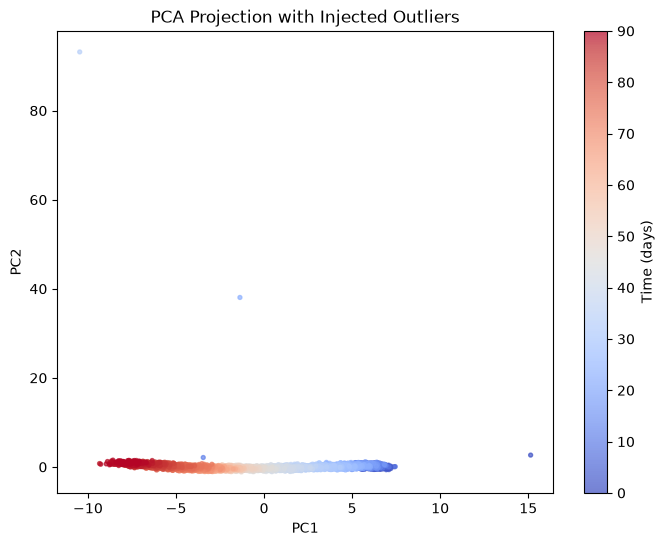

In [104]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_outlier[:, 0],
    X_pca_outlier[:, 1],
    c=df_outlier["Time_Days"],
    cmap="coolwarm",
    s=8,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection with Injected Outliers")

plt.colorbar(scatter, label="Time (days)")

plt.show()

PCA maximizes variance, so an extreme observation can strongly influence the component directions. This example illustrates why it is useful to inspect outliers before interpreting a PCA projection.


In [105]:
#knn kısmındayız
from sklearn.neighbors import NearestNeighbors

# Find the 10 nearest neighbors of each observation
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X_outlier_scaled)

distances, indices = knn.kneighbors(X_outlier_scaled)

# Distance to the 10th nearest neighbor
knn_scores = distances[:, -1]

In [106]:
from sklearn.neighbors import NearestNeighbors

# k = 10 gerçek komşu istiyoruz.
# Noktanın kendisi de distance=0 ile listede bulunduğu için 11 kullanıyoruz.
knn = NearestNeighbors(n_neighbors=11)

# Outlier'lı ve scaled dataset üzerinde komşuları öğren
knn.fit(X_outlier_scaled)

# Her observation için en yakın komşuların
# uzaklıklarını ve indexlerini bul
distances, indices = knn.kneighbors(X_outlier_scaled)

# Her observation'ın 10. gerçek komşusuna olan uzaklığı
# bizim anomaly score'umuz olacak
knn_scores = distances[:, -1]

print("Number of anomaly scores:", len(knn_scores))

Number of anomaly scores: 8000


In [107]:
# Check the anomaly scores of the outliers we injected

for idx in injected_outliers:
    print(
        f"Row {idx}: kNN score = {knn_scores[idx]:.3f}"
    )

Row 100: kNN score = 55.278
Row 500: kNN score = 45.222
Row 1000: kNN score = 58.240
Row 1500: kNN score = 62.520
Row 2000: kNN score = 57.813
Row 3000: kNN score = 95.026
Row 4000: kNN score = 6.783


An anomaly score needs context. Compare the scores for injected anomalies with the score distribution for the remaining observations before choosing a threshold.


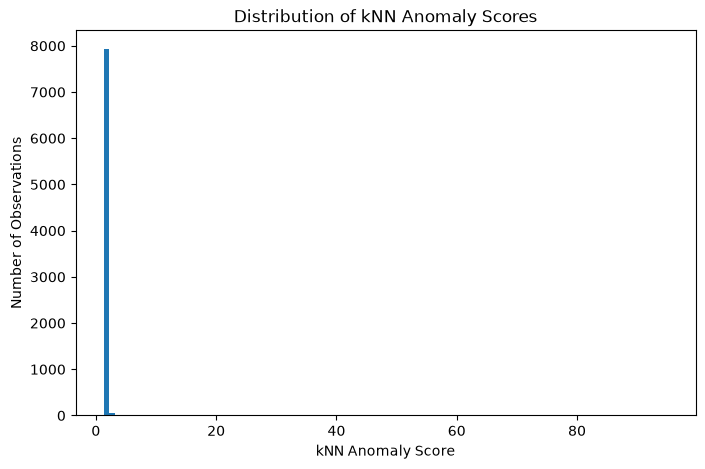

In [108]:
plt.figure(figsize=(8, 5))

plt.hist(knn_scores, bins=100)

plt.xlabel("kNN Anomaly Score")
plt.ylabel("Number of Observations")
plt.title("Distribution of kNN Anomaly Scores")

plt.show()

The extreme injected outliers are far from the main population. This view makes it difficult to inspect the normal-score range, so the next plot focuses on that region to help assess a threshold.


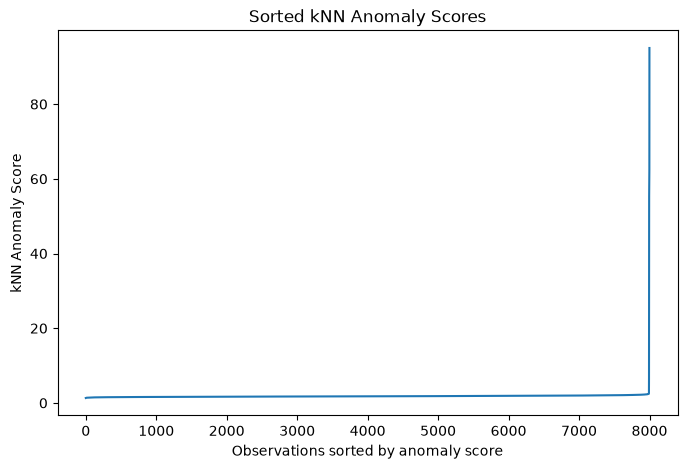

In [109]:
# Sort all kNN anomaly scores from smallest to largest
#sorted k distance scores, yani anomaly score'ları küçükten büyüğe sıralıyoruz
sorted_scores = np.sort(knn_scores)

plt.figure(figsize=(8, 5))

plt.plot(sorted_scores)

plt.xlabel("Observations sorted by anomaly score")
plt.ylabel("kNN Anomaly Score")
plt.title("Sorted kNN Anomaly Scores")

plt.show()

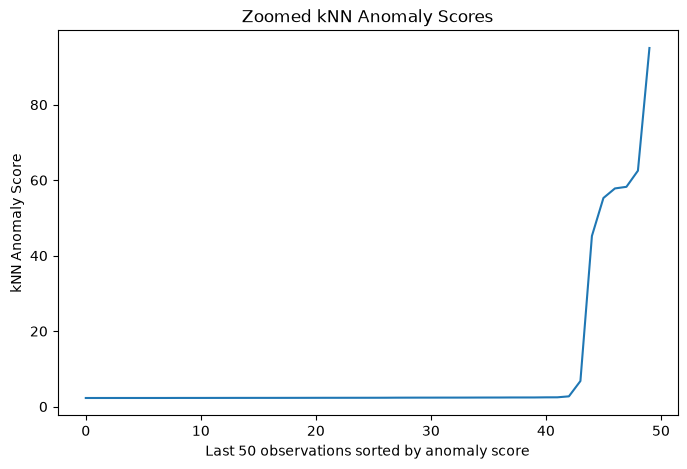

In [110]:
#Şimdi dirseği görmek için grafiğin sadece son kısmına zoom yapalım. Yeni hücre:
sorted_scores = np.sort(knn_scores)

plt.figure(figsize=(8, 5))

plt.plot(sorted_scores[-50:])

plt.xlabel("Last 50 observations sorted by anomaly score")
plt.ylabel("kNN Anomaly Score")
plt.title("Zoomed kNN Anomaly Scores")

plt.show()

In [111]:
# ============================================================
# DETECT OUTLIERS USING kNN ANOMALY SCORES
# ============================================================

# Choose an anomaly-score threshold
threshold = 5

# Find the row indices whose kNN score is above the threshold
detected_outliers = np.where(knn_scores > threshold)[0]

# Print the threshold
print("Threshold:", threshold)

# Print detected outlier rows
print("Detected outliers:")
print(detected_outliers)

# Print the outliers we manually injected
print("\nInjected outliers:")
print(injected_outliers)

# Check which injected outliers were successfully detected
correctly_detected = [
    idx for idx in injected_outliers
    if idx in detected_outliers
]

print("\nCorrectly detected injected outliers:")
print(correctly_detected)

# Check how many points were classified as outliers in total
print("\nTotal number of detected outliers:")
print(len(detected_outliers))

Threshold: 5
Detected outliers:
[ 100  500 1000 1500 2000 3000 4000]

Injected outliers:
[100, 500, 1000, 1500, 2000, 3000, 4000]

Correctly detected injected outliers:
[100, 500, 1000, 1500, 2000, 3000, 4000]

Total number of detected outliers:
7


In [112]:
# ============================================================
# REMOVE DETECTED OUTLIERS
# ============================================================

# Remove observations detected as outliers
df_clean = df_outlier.drop(index=detected_outliers).copy()

# Reset row indices
df_clean = df_clean.reset_index(drop=True)

print("Original contaminated dataset:", df_outlier.shape)
print("Clean dataset:", df_clean.shape)

Original contaminated dataset: (8000, 28)
Clean dataset: (7993, 28)


Sampling asks whether a smaller set of observations can preserve the main process structure while reducing the amount of data to analyze.


In [113]:
# ============================================================
# 5.3.2 EFFECT OF SAMPLING
# RANDOM SAMPLING
# ============================================================

# Take 25% of the cleaned dataset randomly
df_sampled = df_clean.sample(
    frac=0.25,  #datanın %25’ini rastgele seç.
    random_state=42
).sort_values("Time_Days") #seçilen observation’ları tekrar zaman sırasına koyuyoruz.

# Select process features
X_sampled = df_sampled[feature_columns]

# Scale sampled data
scaler_sampled = StandardScaler()
X_sampled_scaled = scaler_sampled.fit_transform(X_sampled)

# Apply PCA
pca_sampled = PCA(n_components=2)
X_pca_sampled = pca_sampled.fit_transform(X_sampled_scaled)

# Show dataset sizes
print("Full cleaned dataset:", df_clean.shape)
print("Sampled dataset:", df_sampled.shape)

# Show explained variance
print("\nSampled PCA explained variance ratio:")
print(pca_sampled.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca_sampled.explained_variance_ratio_.sum())

Full cleaned dataset: (7993, 28)
Sampled dataset: (1998, 28)

Sampled PCA explained variance ratio:
[0.82352379 0.02718201]

Total explained variance:
0.8507057932469184


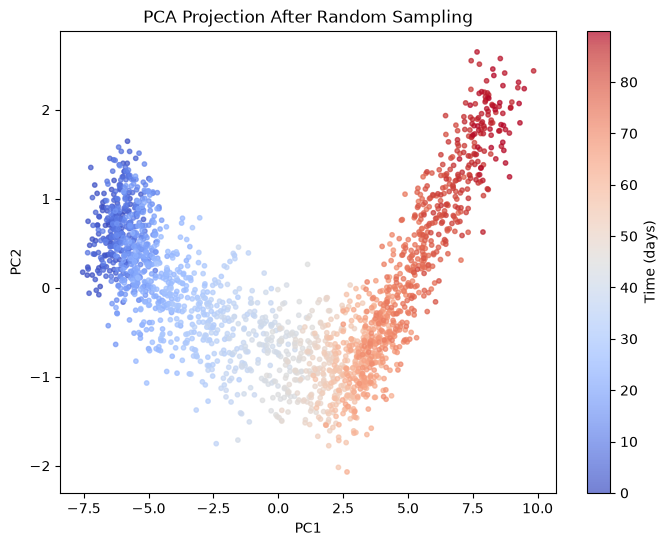

In [114]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_sampled[:, 0],
    X_pca_sampled[:, 1],
    c=df_sampled["Time_Days"],
    cmap="coolwarm",
    s=10,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection After Random Sampling")

plt.colorbar(scatter, label="Time (days)")

plt.show()

In this run, the sample contains about 1,998 observations instead of 7,993 clean observations. The main PCA variance pattern is broadly similar; this comparison is specific to the chosen synthetic dataset and sampling procedure.


DBSCAN uses two main parameters: `eps`, the neighborhood radius, and `min_samples`, the minimum number of nearby observations required to form a dense region. Points outside dense regions are labeled as noise (`-1`).


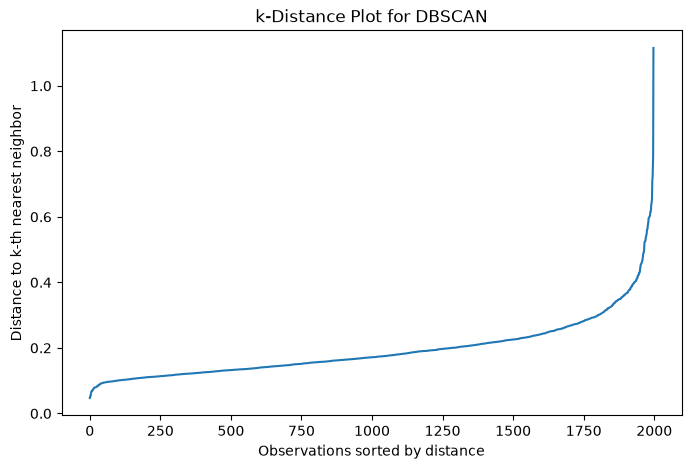

In [115]:
#Şimdi ilk iş: eps seçmek için k-distance grafiği
# ============================================================
# 5.3.3 DBSCAN HYPERPARAMETER SELECTION
# k-DISTANCE PLOT
# ============================================================

from sklearn.neighbors import NearestNeighbors

# DBSCAN için başlangıçta min_samples = 10 kullanacağız
min_samples = 10

# Her PCA observation'ının yakın komşularını bul
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_pca_sampled)

distances, indices = neighbors.kneighbors(X_pca_sampled)

# Her observation için en uzaktaki seçilmiş komşunun mesafesini al
k_distances = distances[:, -1]

# Küçükten büyüğe sırala
k_distances = np.sort(k_distances)

# Plot
plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Observations sorted by distance")
plt.ylabel("Distance to k-th nearest neighbor")
plt.title("k-Distance Plot for DBSCAN")

plt.show()

In [116]:
from sklearn.cluster import DBSCAN

# DBSCAN model
dbscan = DBSCAN(
    eps=0.4,
    min_samples=10
)

# Fit and predict cluster labels
cluster_labels = dbscan.fit_predict(X_pca_sampled)

# Unique cluster labels
print("Cluster labels:")
print(np.unique(cluster_labels))

# Number of points in each cluster
unique_labels, counts = np.unique(
    cluster_labels,
    return_counts=True
)

print("\nCluster sizes:")
for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} observations")

Cluster labels:
[-1  0]

Cluster sizes:
Cluster -1: 11 observations
Cluster 0: 1987 observations


The 11 observations labeled as noise are not necessarily errors. They may lie near the edges of the trajectory, represent sparsely sampled states, or reflect the chosen `eps` value. Review them in context before deciding what they mean.


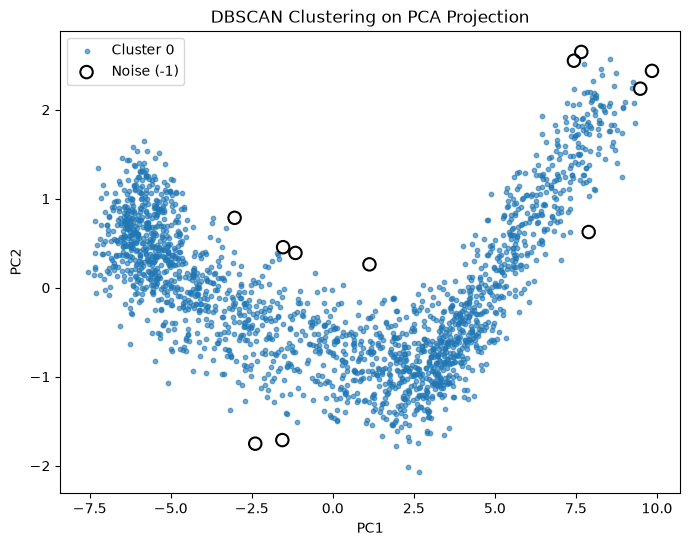

In [117]:
# ============================================================
# VISUALIZE DBSCAN NOISE POINTS
# ============================================================

plt.figure(figsize=(8, 6))

# Plot cluster 0
plt.scatter(
    X_pca_sampled[cluster_labels == 0, 0],
    X_pca_sampled[cluster_labels == 0, 1],
    s=10,
    alpha=0.6,
    label="Cluster 0"
)

# Plot noise points (-1)
plt.scatter(
    X_pca_sampled[cluster_labels == -1, 0],
    X_pca_sampled[cluster_labels == -1, 1],
    s=80,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Noise (-1)"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering on PCA Projection")

plt.legend()
plt.show()

These points were not the injected outliers. They are low-density observations in the clean synthetic dataset. A DBSCAN label of `-1` does not by itself mean that an observation should be removed.


## PaCMAP


PCA finds linear directions that explain variance. PaCMAP builds a nonlinear embedding using neighbor, mid-near, and further point pairs, aiming to preserve local and broader structure. The embedding is useful for visualization, but its axes and distances should not be interpreted as physical measurements.


In [118]:
# ============================================================
# 5.4 PaCMAP ANALYSIS
# ============================================================

# Select the 27 process variables
X_clean = df_clean[feature_columns]

# Standardize the clean dataset
scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

# Apply PaCMAP
pacmap_model = pacmap.PaCMAP(
    n_components=2,
    random_state=42
)

X_pacmap = pacmap_model.fit_transform(X_clean_scaled)

print("PaCMAP projection shape:", X_pacmap.shape)

PaCMAP projection shape: (7993, 2)


The workflow is to exclude `Time_Days` from the features, scale the process variables, apply PaCMAP, and color the resulting two-dimensional embedding by time.


PCA maps the 27-dimensional data to linear components. PaCMAP instead constructs a nonlinear two-dimensional embedding from relationships among observations. Their coordinates are not directly comparable.


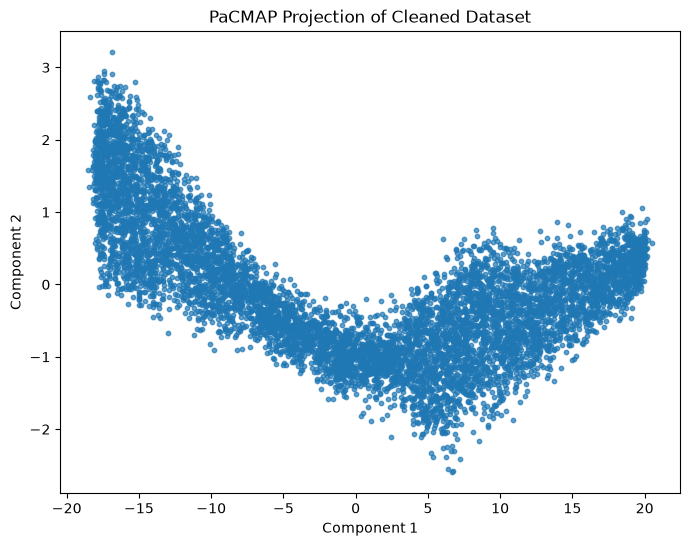

In [119]:
#visualize PaCMAP projection
plt.figure(figsize=(8, 6))
plt.scatter(X_pacmap[:, 0], X_pacmap[:, 1], s=10, alpha=0.7)
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PaCMAP Projection of Cleaned Dataset")
plt.show()


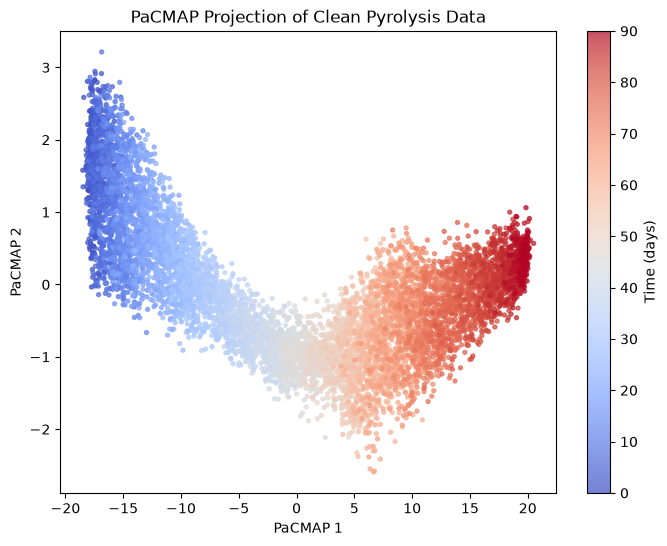

In [120]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pacmap[:, 0],
    X_pacmap[:, 1],
    c=df_clean["Time_Days"],
    cmap="coolwarm",
    s=8,
    alpha=0.7
)

plt.xlabel("PaCMAP 1")
plt.ylabel("PaCMAP 2")
plt.title("PaCMAP Projection of Clean Pyrolysis Data")

plt.colorbar(scatter, label="Time (days)")

plt.show()

Some regions appear more spread out in the PaCMAP plot than in the PCA projection. This can reflect how the nonlinear embedding arranges local neighborhoods; it does not establish a separate operating regime.


PCA and PaCMAP both recover the dominant continuous operating-cycle structure. PaCMAP does not fundamentally alter the global U-shaped trajectory, but it redistributes local neighborhoods and appears to expand some intermediate process regions, particularly around PaCMAP component 1 values of approximately 5–10.

DBSCAN found little separation in the PCA projection. Its `eps` value cannot be reused automatically for PaCMAP because the embedding has a different coordinate scale. The next cells inspect distances to choose a suitable range for this representation.


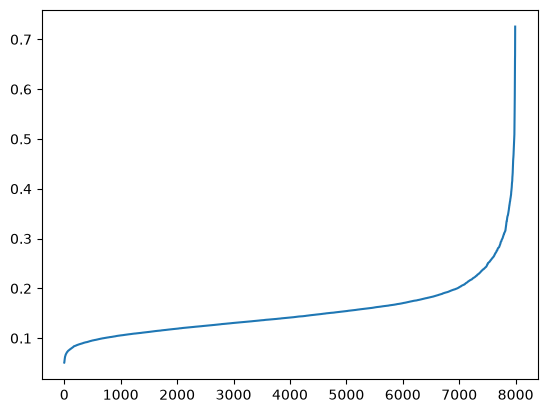

In [121]:
neighbors = NearestNeighbors(n_neighbors=10).fit(X_pacmap)
distances, _ = neighbors.kneighbors(X_pacmap)

k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.show()

In [ ]:
#dbscan
labels_pacmap = DBSCAN(eps=0.3, min_samples=10).fit_predict(X_pacmap)

np.unique(labels_pacmap, return_counts=True) #np.unique() bir array içindeki farklı değerleri bulur.

DBSCAN tests whether the PaCMAP embedding contains dense groups under the selected parameters. In this run, the points largely follow one continuous trajectory rather than clearly separated operating clusters.


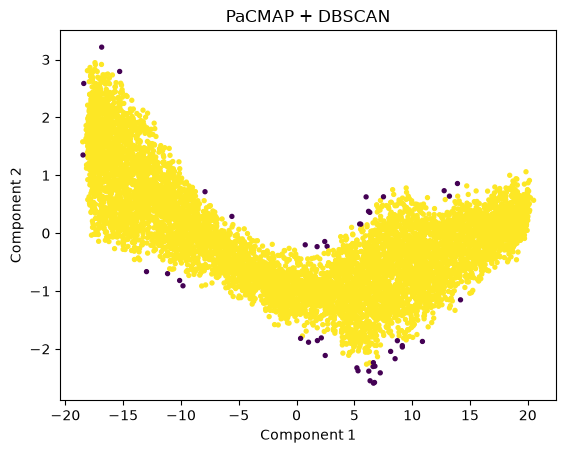

In [123]:
plt.scatter(
    X_pacmap[:, 0],
    X_pacmap[:, 1],
    c=labels_pacmap,
    s=8
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PaCMAP + DBSCAN")
plt.show()

PaCMAP arranges some local structure differently from PCA, but this synthetic dataset still appears to follow a continuous trajectory rather than distinct operating regimes.


## t-SNE


t-SNE emphasizes local neighborhoods and can help visualize nearby observations. Distances between far-apart groups in a t-SNE plot are not reliable measures of how different the corresponding process states are. Apparent groups should be checked against the original variables and parameter choices.


Perplexity is a scale parameter related to the number of neighbors considered by t-SNE. Lower values emphasize more local structure; higher values produce a broader neighborhood view. It is a qualitative guide, not a literal neighbor count.


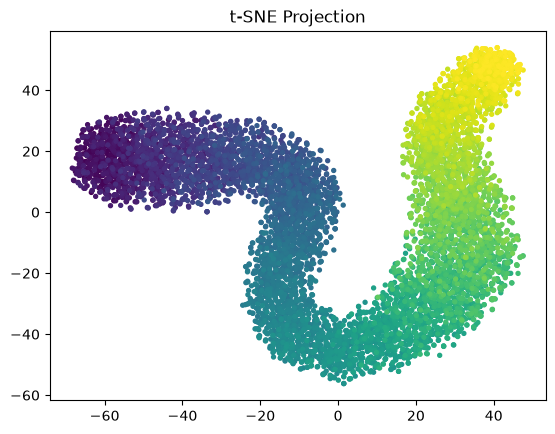

In [124]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_clean_scaled)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df_clean["Time_Days"],
    s=8
)

plt.title("t-SNE Projection")
plt.show()

`n_components=2` creates a two-dimensional embedding; `perplexity=30` is the selected neighborhood scale; and `random_state=42` makes the run reproducible. The embedding is colored by `Time_Days`. Unlike PCA, t-SNE does not provide explained-variance ratios.


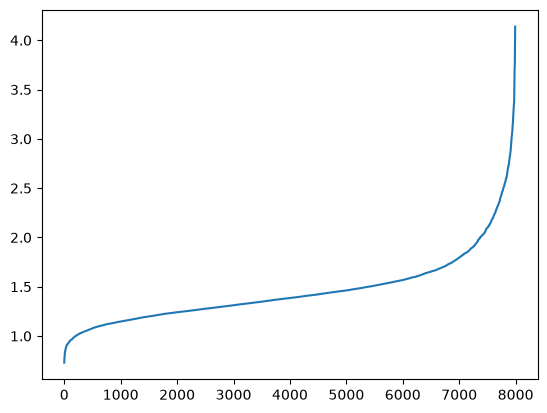

In [125]:
#eps seçiyoruz
neighbors = NearestNeighbors(n_neighbors=10).fit(X_tsne)
distances, _ = neighbors.kneighbors(X_tsne)

k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.show()

In [126]:
labels_tsne = DBSCAN(eps=2.0, min_samples=10).fit_predict(X_tsne)

np.unique(labels_tsne, return_counts=True)

(array([-1,  0,  1]), array([ 155, 7830,    8]))

A compact group separated from the main cloud may indicate a local subregion in this embedding. Check whether it also has a coherent pattern in the original process variables; otherwise, it may be sensitive to embedding or clustering settings.


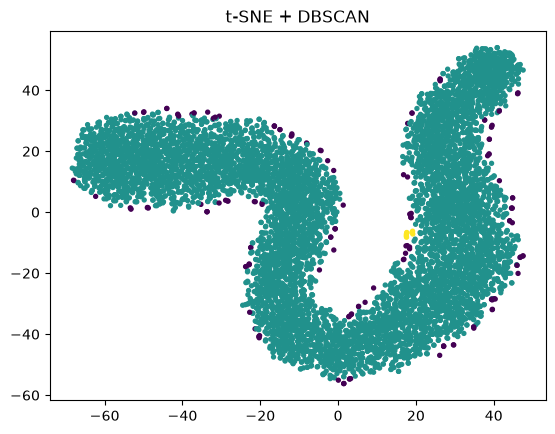

In [127]:
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_tsne,
    s=8
)

plt.title("t-SNE + DBSCAN")
plt.show()

In [128]:
#o sekiz noktanın hangi günlerde olduguna bakalım
cluster1_idx = np.where(labels_tsne == 1)[0]

df_clean.iloc[cluster1_idx][["Time_Days"]]

,Time_Days
5116,57.640955
5404,60.881360
5534,62.344043
5998,67.564696
6025,67.868484
6059,68.251031
6422,72.335292
6668,75.103138


The eight observations form a small local group in this t-SNE embedding. Because the synthetic variables include time-dependent trends, late-cycle similarity is plausible by construction. The group is exploratory and should not be treated as a validated transient event or real-world operating state.


Compare the standardized process-variable means for these eight observations with those of the main cluster to see which variables distinguish the group in this run.


In [ ]:
diff = pd.Series(
    X_clean_scaled[labels_tsne == 1].mean(axis=0)
    - X_clean_scaled[labels_tsne == 0].mean(axis=0),
    index=feature_columns
)

diff.abs().sort_values(ascending=False).head(10)
#sarı noktaların her feature için ortalama değerleri ile mavi noktaların her feature için ortalama değerleri arasındaki farkı buluyoruz. Bu farkın mutlak değerini alıp büyükten küçüğe sıralıyoruz. Böylece hangi feature’ların bu iki cluster’ı ayırmada en etkili olduğunu görebiliyoruz.

In [130]:
#yönleri görelim
print("Higher in Cluster 1:")
print(diff.sort_values(ascending=False).head(10))

print("\nLower in Cluster 1:")
print(diff.sort_values().head(10))

Higher in Cluster 1:
Crossover_Temp_Coil_6    1.018299
Furnace_Temp             0.982387
Cracking_Temp_Coil_6     0.921759
Cracking_Temp_Coil_5     0.801598
Crossover_Temp_Coil_1    0.791525
Steam_Flow_Coil_3        0.716708
Overall_Outlet_Temp      0.713687
Steam_Flow_Coil_5        0.655784
Crossover_Temp_Coil_3    0.639495
Steam_Flow_Coil_1        0.629472
dtype: float64

Lower in Cluster 1:
HC_Flow_Coil_6          -1.146738
HC_Flow_Coil_3          -1.012612
HC_Flow_Coil_1          -0.919261
Total_HC_Flow           -0.917733
HC_Flow_Coil_2          -0.801337
HC_Flow_Coil_5          -0.695531
HC_Flow_Coil_4          -0.644255
Cracking_Temp_Coil_4     0.288600
Steam_Flow_Coil_4        0.295377
Crossover_Temp_Coil_4    0.351955
dtype: float64


## Summary and limitations

This notebook builds a synthetic pyrolysis-process dataset and explores scaling, PCA, injected-outlier detection with k-nearest neighbors, sampling, DBSCAN, PaCMAP, and t-SNE. In the saved run, the first two PCs capture most of the designed variation; DBSCAN on the PCA and PaCMAP views does not produce clearly separated operating regimes, while t-SNE plus DBSCAN identifies a small eight-observation local group for further inspection.

The time-dependent trends and variable relationships were deliberately specified when generating the data. Therefore, recovering a cycle-like pattern is an expected property of this exercise, not an independent discovery. The data are synthetic, there is no direct coke-deposition measurement, and the results are not validated against plant data. The small t-SNE group is exploratory and depends on embedding and clustering choices.
